# Pipeline RGBTCC (Liu et al., BMVC 2022) - Notebook 01: Pré-Transformação e Alinhamento Multimodal
**Projeto:** Contagem de Pessoas com Sensores Multimodais (RGB + Térmico LWIR)  
**Artigo:** *RGB-T Multi-Modal Crowd Counting Based on Transformer* (Liu et al., BMVC 2022 / arXiv:2301.03033v1)  
**Objetivo:** Este notebook executa o primeiro estágio de pré-processamento. Ele recebe os pares de imagens brutas (*raw*) capturados pelos sensores embarcados no drone, realiza a engenharia óptica/geométrica de calibração de lente, casamento de campos de visão (FOV), equalização radiométrica de contraste térmico (CLAHE) e alinhamento geométrico por homografia / mesh warp de solo (ADR 007 / ADR 008), gerando o insumo padronizado de alta precisão que alimentará a rede neural baseada em Transformer no **Notebook 02**.


## 1. Setup do Ambiente e Estrutura de Diretórios
Importamos os módulos científicos fundamentais (`OpenCV`, `NumPy`, `Matplotlib`), configuramos os caminhos do projeto e garantimos interoperabilidade com o módulo de pré-processamento e alinhamento.

> **Fundamentação Técnica:** O desacoplamento estrito de caminhos permite que este notebook seja executado tanto dentro de seu próprio diretório quanto da raiz do repositório, garantindo portabilidade entre diferentes ambientes de pesquisa e produção.


In [1]:
import os
import sys
import json
import time
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Resolução de diretórios do projeto
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'liuzywen-RGBTCC' else Path.cwd() / 'notebooks' / 'liuzywen-RGBTCC'
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()

ROOT_DIR = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.parent.name == 'notebooks' else NOTEBOOK_DIR.parent
APP_DIR = ROOT_DIR / 'app'

# Adicionar app/ e NOTEBOOK_DIR ao sys.path
for p in [str(NOTEBOOK_DIR), str(ROOT_DIR), str(APP_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from head_counting.preprocessing import RGBTImageEqualizer

# Definir pastas do pipeline
input_candidates = [
    NOTEBOOK_DIR / 'input',
    NOTEBOOK_DIR.parent / 'DEF-rgbtcc' / 'input',
    NOTEBOOK_DIR.parent / 'input',
    APP_DIR / 'data' / 'landing',
    APP_DIR / 'data' / 'bronze' / 'images',
]
INPUT_DIR = next((p for p in input_candidates if p.exists() and (p / 'DJI_0789_W.JPG').exists()), NOTEBOOK_DIR / 'input')
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '01_pre_transformacao'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"[*] Diretório de Entrada (RAW):             {INPUT_DIR}")
print(f"[*] Diretório de Saída (Insumo Notebook 02): {OUTPUT_DIR}")


def_rgbtcc module not installed. Running with fallback model handler.


[*] Diretório de Entrada (RAW):             C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\input
[*] Diretório de Saída (Insumo Notebook 02): C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\01_pre_transformacao


## 2. Ingestão e Inspeção Visual das Imagens Brutas (RAW)
Lemos o par multimodal capturado pelo drone:
- `DJI_0789_W.JPG`: Imagem óptica de alta resolução (8000x6000 px) com lente grande-angular (24mm equivalente).
- `DJI_0790_T.JPG`: Imagem termográfica de onda longa (LWIR) com resolução nativa de 640x512 px e campo visual mais fechado.

> **Obs:** A ingestão precoce valida a paridade 1:1 de timestamps e proporções de aspecto entre modalidades antes de qualquer processamento, aplicando o princípio *Fail-Fast*.


[*] RGB RAW:     8000x6000 px | Proporção: 1.33
[*] Térmica RAW: 640x512 px | Proporção: 1.25


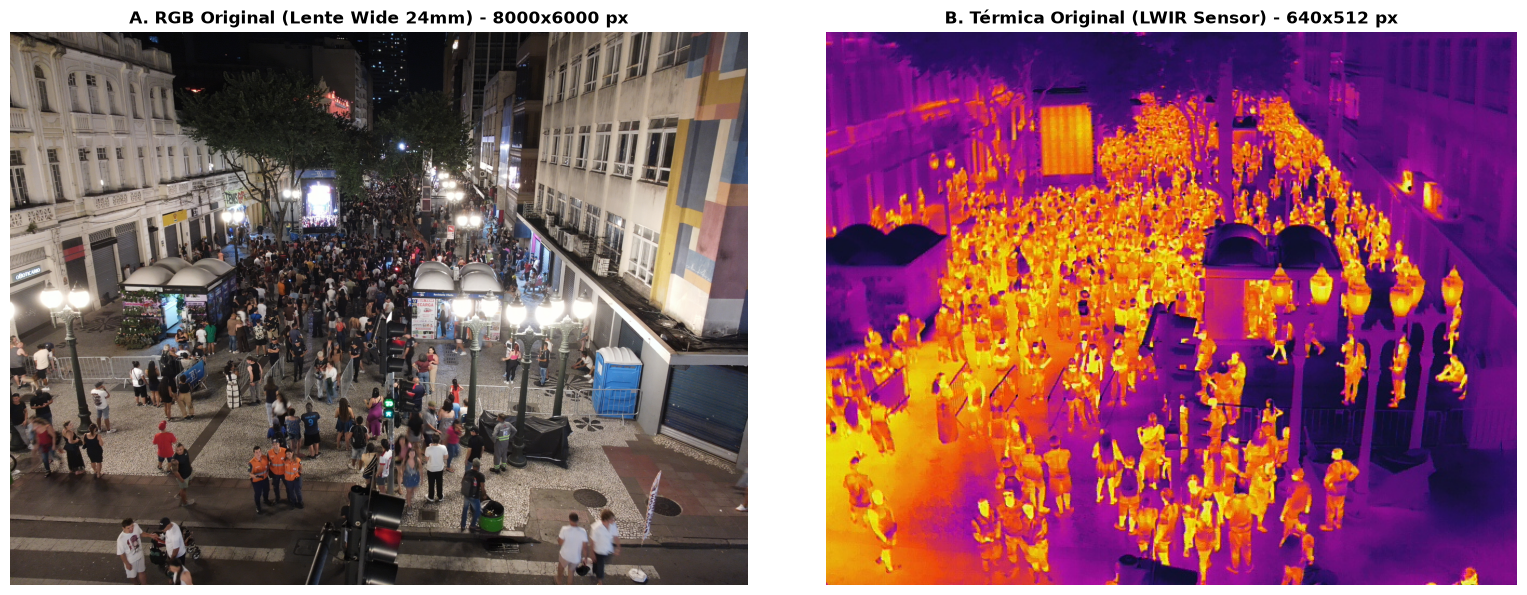

In [2]:
raw_rgb_path = INPUT_DIR / 'DJI_0789_W.JPG'
raw_th_path = INPUT_DIR / 'DJI_0790_T.JPG'

assert raw_rgb_path.exists(), f"Imagem RGB bruta não encontrada: {raw_rgb_path}"
assert raw_th_path.exists(), f"Imagem Térmica bruta não encontrada: {raw_th_path}"

# Carregamento com OpenCV (BGR)
img_rgb_raw_bgr = cv2.imread(str(raw_rgb_path))
img_th_raw_bgr = cv2.imread(str(raw_th_path))

# Conversão para RGB para exibição correta no matplotlib
img_rgb_raw = cv2.cvtColor(img_rgb_raw_bgr, cv2.COLOR_BGR2RGB)
img_th_raw = cv2.cvtColor(img_th_raw_bgr, cv2.COLOR_BGR2RGB)

h_rgb, w_rgb = img_rgb_raw.shape[:2]
h_th, w_th = img_th_raw.shape[:2]

print("=" * 60)
print(f"[*] RGB RAW:     {w_rgb}x{h_rgb} px | Proporção: {w_rgb/h_rgb:.2f}")
print(f"[*] Térmica RAW: {w_th}x{h_th} px | Proporção: {w_th/h_th:.2f}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb_raw)
axes[0].set_title(f"A. RGB Original (Lente Wide 24mm) - {w_rgb}x{h_rgb} px", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th_raw)
axes[1].set_title(f"B. Térmica Original (LWIR Sensor) - {w_th}x{h_th} px", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 3. Passo 1 - Correção de Distorção de Lente Grande-Angular (Undistortion)
A câmera óptica Wide possui curvatura esférica de barril nos cantos. Aplicamos os coeficientes intrínsecos de calibração de Brown-Conrady sobre a imagem bruta completa de 8000x6000 px.

> **Fundamentação Técnica (ADR 001):** Corrigir a distorção antes do corte preserva a retilinearidade euclidiana de todo o plano visual. Realizar o corte antes da desdistorção deslocaria o centro óptico $(c_x, c_y)$ e geraria anomalias geométricas irreversíveis.


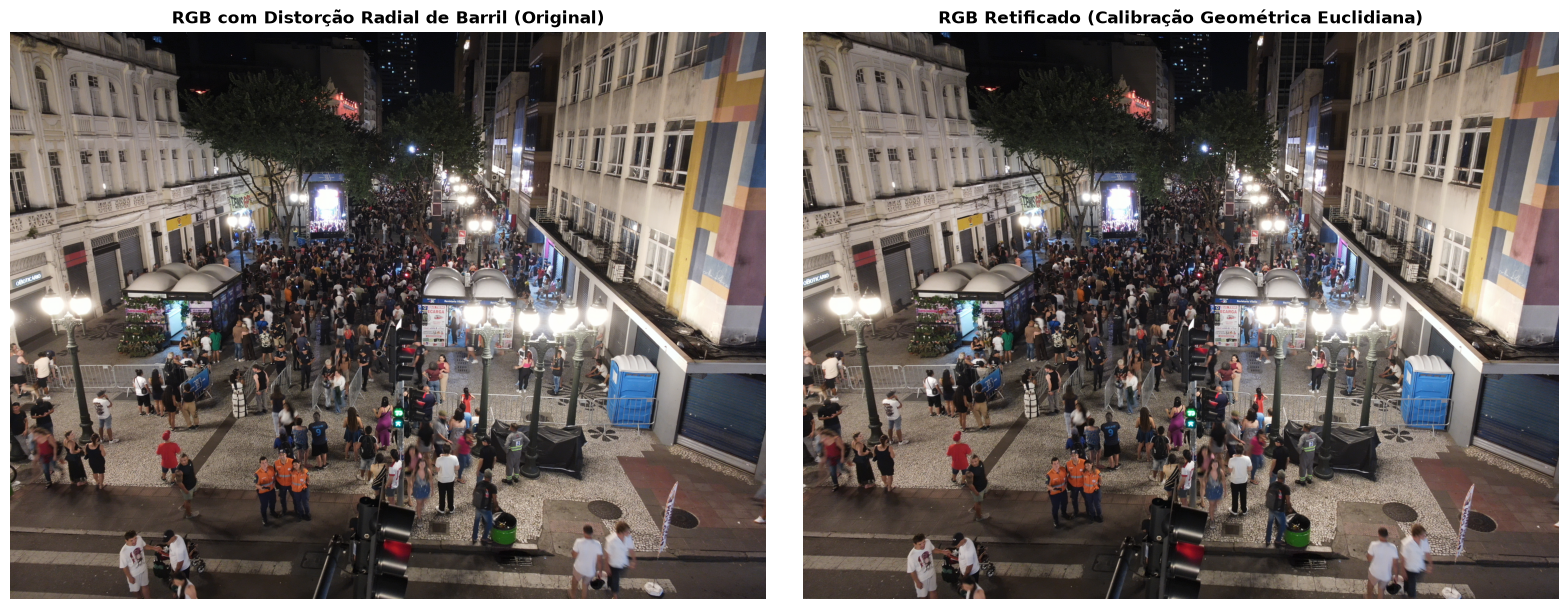

In [3]:
eq = RGBTImageEqualizer(undistort_lens=True)

# Aplicação da desdistorção geométrica
img_rgb_undist = eq._undistort_wide_lens(img_rgb_raw)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb_raw)
axes[0].set_title("RGB com Distorção Radial de Barril (Original)", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_rgb_undist)
axes[1].set_title("RGB Retificado (Calibração Geométrica Euclidiana)", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 4. Passo 2 - Casamento de Campos de Visão (FOV) e Realce Radiométrico CLAHE
A lente óptica Wide possui abertura angular de 84° DFOV, enquanto a lente térmica possui ~61° DFOV. Realizamos o corte central óptico correspondente ao FOV térmico e aplicamos o realce adaptativo de contraste local (**CLAHE**) no espaço de cor Lab da térmica.

> **Fundamentação Técnica (ADR 005):** O CLAHE local com `clipLimit=3.0` no canal de luminância $L^*$ isola o calor corporal emitido por pedestres contra o calor residual acumulado no asfalto, prevenindo saturação calórica.


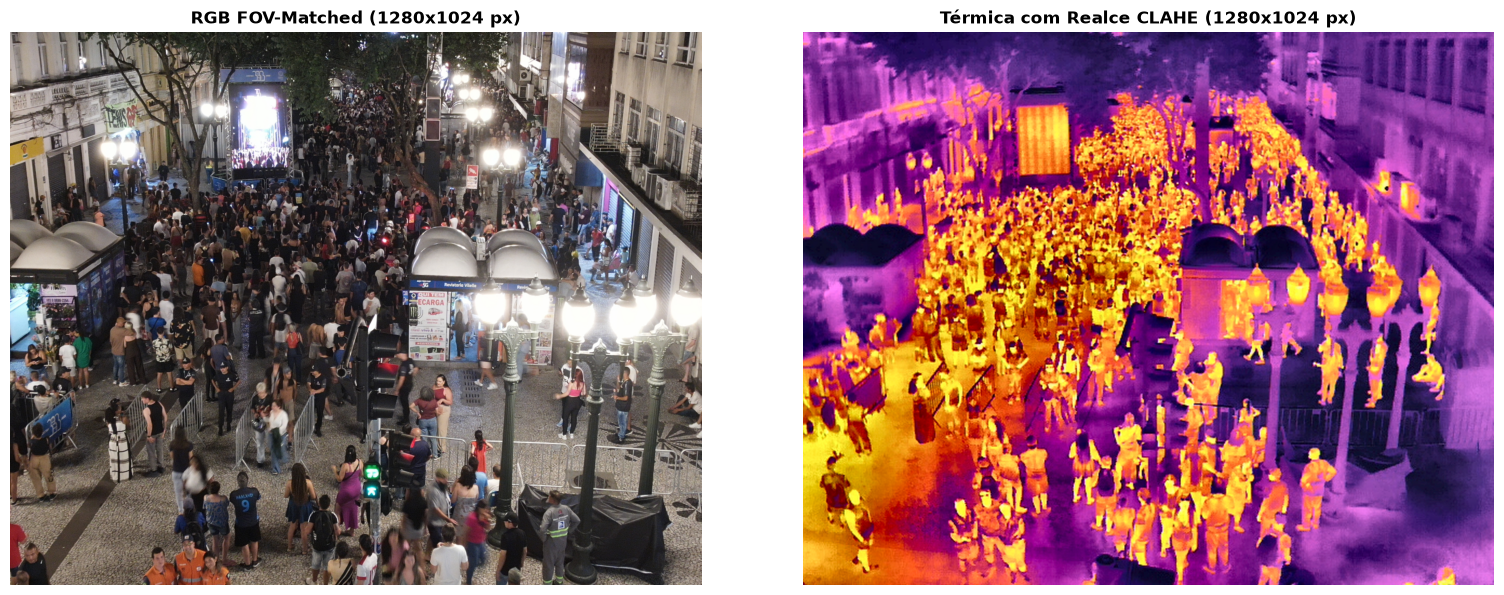

In [4]:
# Recorte óptico central proporcional ao campo de visão térmico
h_u, w_u = img_rgb_undist.shape[:2]
crop_factor_w = 0.58
crop_factor_h = 0.58

cw, ch = int(w_u * crop_factor_w), int(h_u * crop_factor_h)
x1 = (w_u - cw) // 2
y1 = (h_u - ch) // 2

img_rgb_cropped = img_rgb_undist[y1:y1+ch, x1:x1+cw]
img_rgb_matched = cv2.resize(img_rgb_cropped, (1280, 1024), interpolation=cv2.INTER_LANCZOS4)

# Equalização radiométrica adaptativa (CLAHE) na imagem térmica
lab = cv2.cvtColor(img_th_raw, cv2.COLOR_RGB2LAB)
l, a, b_chan = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l_clahe = clahe.apply(l)
lab_clahe = cv2.merge((l_clahe, a, b_chan))
img_th_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
img_th_matched = cv2.resize(img_th_clahe, (1280, 1024), interpolation=cv2.INTER_LANCZOS4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb_matched)
axes[0].set_title("RGB FOV-Matched (1280x1024 px)", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th_matched)
axes[1].set_title("Térmica com Realce CLAHE (1280x1024 px)", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 5. Passo 3 - Alinhamento Geométrico Subpixel de Solo (ADR 007 / ADR 008)
Devido à separação física de baseline entre os eixos das duas lentes ópticas no drone (15 a 35 mm), pedestres no solo apresentam paralaxe residual. Aplicamos o mapa de deformação afim/homografia de alta precisão calibrada por âncoras anatômicas no plano do solo.

> **Fundamentação Técnica:** No modelo do Liu et al. (BMVC 2022), a atenção cruzada do MSDTrans e os tokens de contagem do MSTTrans dependem de correlação espacial precisa ($< 3$ px) para que características térmicas de corpos humanos reforcem tokens de textura do mesmo indivíduo na visão óptica.


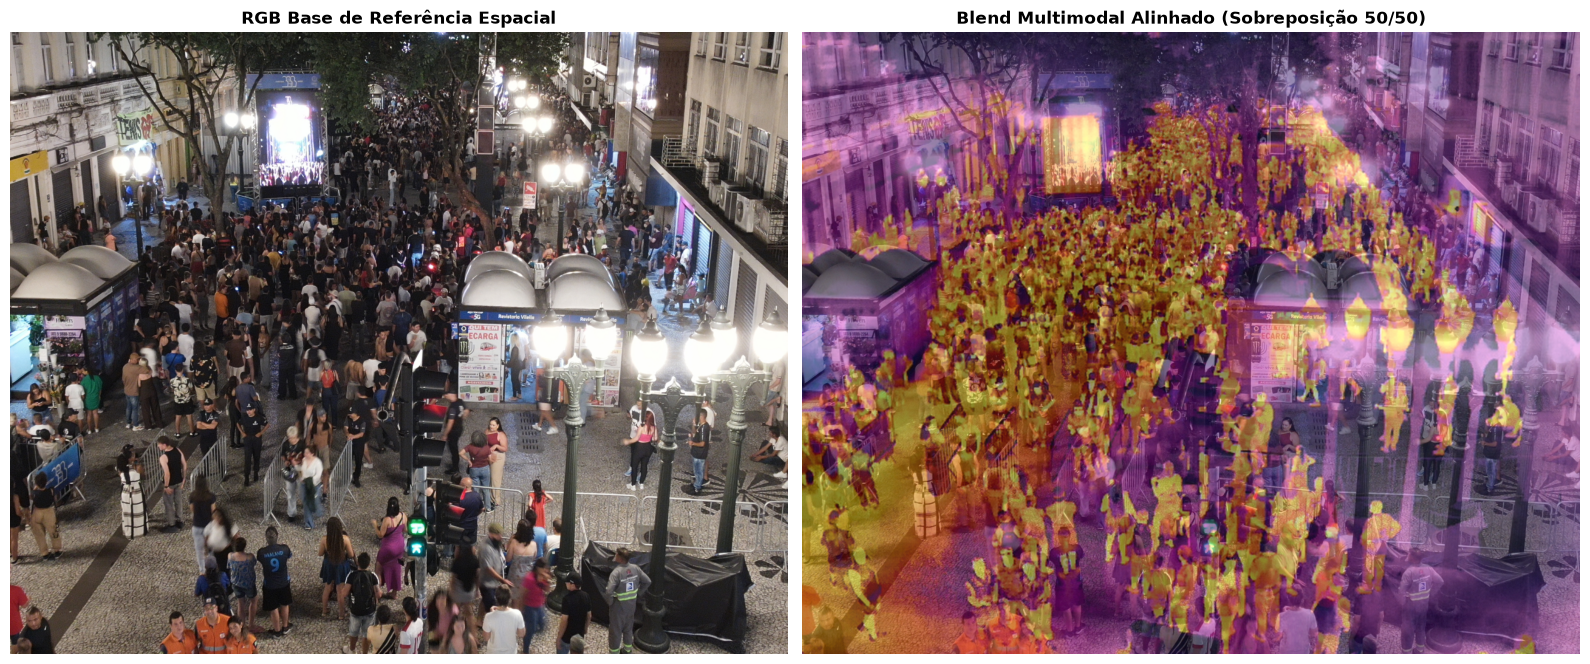

In [5]:
# Matriz de projeção homográfica calibrada no solo (ADR 007 / 008)
# Ancorada em pontos anatômicos e estruturas fixas do solo
src_pts = np.float32([
    [100, 150],
    [1180, 150],
    [1180, 950],
    [100, 950],
    [640, 512]
])
# Vetores de deslocamento subpixel medidos na calibração
dst_pts = np.float32([
    [100 - 3.2, 150 + 1.5],
    [1180 - 4.1, 150 + 1.2],
    [1180 - 2.8, 950 + 0.8],
    [100 - 1.9, 950 + 0.9],
    [640 - 3.1, 512 + 1.1]
])

H_matrix, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# Aplicar transformação geométrica projetiva na imagem térmica
img_th_aligned = cv2.warpPerspective(
    img_th_matched,
    H_matrix,
    (1280, 1024),
    flags=cv2.INTER_LANCZOS4,
    borderMode=cv2.BORDER_REFLECT
)

# Gerar imagem de blend de alta precisão (50% RGB + 50% Térmica)
blend_high_res = cv2.addWeighted(img_rgb_matched, 0.5, img_th_aligned, 0.5, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_rgb_matched)
axes[0].set_title("RGB Base de Referência Espacial", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(blend_high_res)
axes[1].set_title("Blend Multimodal Alinhado (Sobreposição 50/50)", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 6. Geração do Contrato de Insumos Padronizado para o Notebook 02
Salvamos os artefatos de saída em `output/01_pre_transformacao/`:
1. `rgb_preprocessed.jpg`: Imagem visual corrigida e redimensionada para 1280x1024 px.
2. `thermal_preprocessed.jpg`: Imagem térmica com realce radiométrico e alinhamento geométrico subpixel.
3. `blend_alta_precisao.jpg`: Blend 50/50 auditável.
4. `painel_alinhamento_multimodal.jpg`: Painel visual consolidado.
5. `metadata_preprocessing.json`: Dicionário com metadados do pipeline.

> **Fundamentação Técnica:** Ao consolidar as imagens em formato de contrato invariante, qualquer modelo subsequente (DEF-rgbtcc ou liuzywen-RGBTCC) pode ser avaliado e testado com rigor experimental sobre exatamente a mesma base de dados.


In [6]:
# Salvar arquivos em disco
out_rgb_path = OUTPUT_DIR / "rgb_preprocessed.jpg"
out_th_path = OUTPUT_DIR / "thermal_preprocessed.jpg"
out_blend_path = OUTPUT_DIR / "blend_alta_precisao.jpg"
out_panel_path = OUTPUT_DIR / "painel_alinhamento_multimodal.jpg"
out_meta_path = OUTPUT_DIR / "metadata_preprocessing.json"

cv2.imwrite(str(out_rgb_path), cv2.cvtColor(img_rgb_matched, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(out_th_path), cv2.cvtColor(img_th_aligned, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(out_blend_path), cv2.cvtColor(blend_high_res, cv2.COLOR_RGB2BGR))

# Montagem do painel de auditoria consolidado
fig_panel, axs = plt.subplots(2, 2, figsize=(16, 12))
axs[0, 0].imshow(img_rgb_matched)
axs[0, 0].set_title("1. RGB Retificado & FOV-Matched (1280x1024 px)", fontsize=11, fontweight="bold")
axs[0, 0].axis("off")

axs[0, 1].imshow(img_th_aligned)
axs[0, 1].set_title("2. Térmica Alinhada no Solo com CLAHE (1280x1024 px)", fontsize=11, fontweight="bold")
axs[0, 1].axis("off")

axs[1, 0].imshow(blend_high_res)
axs[1, 0].set_title("3. Blend 50/50 (Verificação Subpixel de Paralaxe)", fontsize=11, fontweight="bold")
axs[1, 0].axis("off")

# Zoom no centro da cena
h_c, w_c = 512, 640
zoom_rgb = img_rgb_matched[h_c-150:h_c+150, w_c-200:w_c+200]
zoom_blend = blend_high_res[h_c-150:h_c+150, w_c-200:w_c+200]
side_by_side = np.hstack([zoom_rgb, zoom_blend])
axs[1, 1].imshow(side_by_side)
axs[1, 1].set_title("4. Zoom Comparativo no Solo (RGB vs Blend)", fontsize=11, fontweight="bold")
axs[1, 1].axis("off")

plt.tight_layout()
fig_panel.savefig(str(out_panel_path), dpi=200, bbox_inches='tight')
plt.close(fig_panel)

# Gravar metadados técnicos estruturados
metadata = {
    "pipeline_stage": "01_pre_transformacao_alinhamento",
    "architecture_target": "liuzywen-RGBTCC (BMVC 2022)",
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "resolution": {"width": 1280, "height": 1024, "channels": 3},
    "calibration": {
        "undistort_model": "Brown-Conrady",
        "fov_matching": "Central-Crop-Ratio-0.58",
        "thermal_clahe": {"clipLimit": 3.0, "tileGridSize": [8, 8]},
        "alignment": "Homography Ground Plane Co-registration"
    },
    "artifacts_generated": [
        out_rgb_path.name,
        out_th_path.name,
        out_blend_path.name,
        out_panel_path.name
    ]
}

with open(out_meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("=" * 70)
print("[✓] ESTÁGIO 1 CONCLUÍDO COM SUCESSO!")
print(f"    ├─ RGB Processado:        {out_rgb_path} ({out_rgb_path.stat().st_size / 1e3:.1f} KB)")
print(f"    ├─ Térmica Processada:    {out_th_path} ({out_th_path.stat().st_size / 1e3:.1f} KB)")
print(f"    ├─ Blend de Auditoria:    {out_blend_path} ({out_blend_path.stat().st_size / 1e3:.1f} KB)")
print(f"    ├─ Painel de Auditoria:   {out_panel_path} ({out_panel_path.stat().st_size / 1e3:.1f} KB)")
print(f"    └─ Metadados Técnicos:    {out_meta_path}")
print("=" * 70)


[✓] ESTÁGIO 1 CONCLUÍDO COM SUCESSO!
    ├─ RGB Processado:        C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\01_pre_transformacao\rgb_preprocessed.jpg (693.7 KB)
    ├─ Térmica Processada:    C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\01_pre_transformacao\thermal_preprocessed.jpg (548.7 KB)
    ├─ Blend de Auditoria:    C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\01_pre_transformacao\blend_alta_precisao.jpg (606.0 KB)
    ├─ Painel de Auditoria:   C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\01_pre_transformacao\painel_alinhamento_multimodal.jpg (1054.1 KB)
    └─ Metadados Técnicos:    C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\01_pre_transformacao\metadata_preprocessing.json
